In [ ]:
!ls

nifty.zip  sample_data


In [ ]:
!unzip -q -o nifty.zip -d nifty
!ls nifty | head

[nifty.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of nifty.zip or
        nifty.zip.zip, and cannot find nifty.zip.ZIP, period.
ls: cannot access 'nifty': No such file or directory


In [ ]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
STOCK = "RELIANCE"
path = glob.glob(f"nifty/**/{STOCK}.csv", recursive=True)[0]
df = pd.read_csv(path, parse_dates=["Date"]).sort_values("Date").set_index("Date")
print(df.shape)
df.head()

IndexError: list index out of range

In [ ]:
!unzip -q -o nifty.zip -d nifty
!ls nifty | head

ADANIPORTS.csv
ASIANPAINT.csv
AXISBANK.csv
BAJAJ-AUTO.csv
BAJAJFINSV.csv
BAJFINANCE.csv
BHARTIARTL.csv
BPCL.csv
BRITANNIA.csv
CIPLA.csv


In [6]:
STOCK = "RELIANCE"
path = glob.glob(f"nifty/**/{STOCK}.csv", recursive=True)[0]
df = pd.read_csv(path, parse_dates=["Date"]).sort_values("Date").set_index("Date")
print(df.shape)
df.head()

(5306, 14)


,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,
2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


             Close
count  5306.000000
mean   1011.316839
std     571.046753
min     203.200000
25%     572.512500
50%     938.275000
75%    1248.275000
max    3220.850000


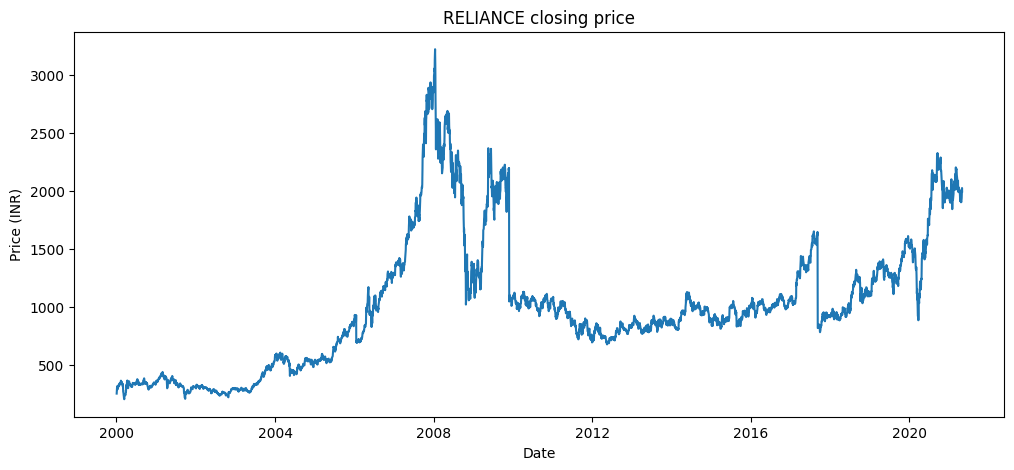

In [7]:
data = df[["Close"]].dropna()
print(data.describe())
plt.figure(figsize=(12,5))
plt.plot(data.index, data["Close"])
plt.title(f"{STOCK} closing price")
plt.xlabel("Date"); plt.ylabel("Price (INR)")
plt.show()

In [8]:
WINDOW = 60
split = int(len(data) * 0.8)

scaler = MinMaxScaler()
scaler.fit(data.values[:split])
scaled = scaler.transform(data.values)

def make_sequences(arr, window):
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i-window:i, 0])
        y.append(arr[i, 0])
    return np.array(X)[..., np.newaxis], np.array(y)

X_all, y_all = make_sequences(scaled, WINDOW)
cut = split - WINDOW
X_train, y_train = X_all[:cut], y_all[:cut]
X_test,  y_test  = X_all[cut:], y_all[cut:]
print(X_train.shape, X_test.shape)

(4184, 60, 1) (1062, 60, 1)


In [9]:
model = Sequential([
    Input(shape=(WINDOW, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - loss: 0.0056 - val_loss: 1.9244e-04
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - loss: 0.0017 - val_loss: 2.0656e-04
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.0015 - val_loss: 8.7244e-05
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 0.0015 - val_loss: 8.8184e-05
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 0.0014 - val_loss: 1.6923e-04
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - loss: 0.0013 - val_loss: 1.3509e-04
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 0.0013 - val_loss: 1.5627e-04
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 0.0013 - val_loss: 1.0770e-04


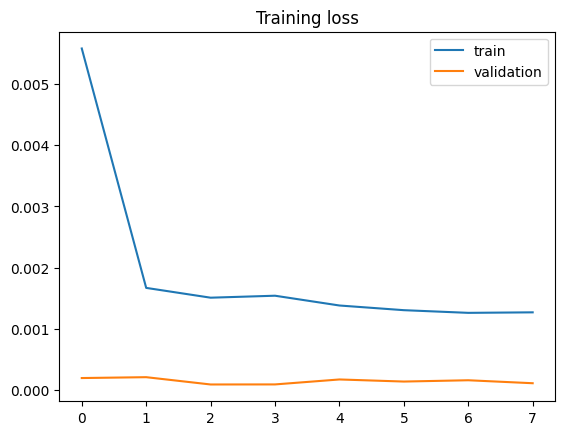

In [10]:
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=30, batch_size=32,
                    validation_split=0.1, callbacks=[es], verbose=1)

plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Training loss"); plt.legend(); plt.show()

In [11]:
pred = scaler.inverse_transform(model.predict(X_test))
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(actual, pred))
mae = mean_absolute_error(actual, pred)
mape = np.mean(np.abs((actual - pred) / actual)) * 100
print(f"LSTM  RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}%")

naive = scaler.inverse_transform(X_test[:, -1, :])
print(f"Naive baseline RMSE: {np.sqrt(mean_squared_error(actual, naive)):.2f}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
LSTM  RMSE: 78.83 | MAE: 48.00 | MAPE: 3.76%
Naive baseline RMSE: 37.91


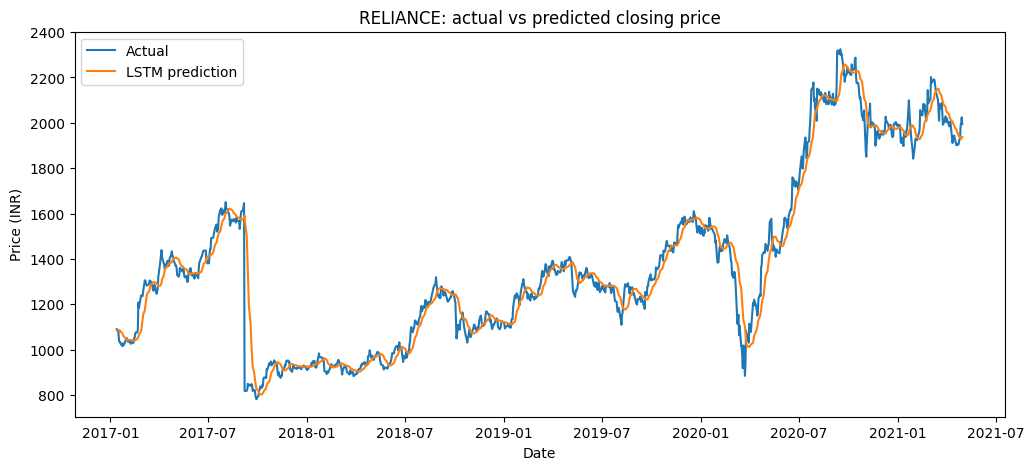

In [12]:
test_dates = data.index[split:]
plt.figure(figsize=(12,5))
plt.plot(test_dates, actual, label="Actual")
plt.plot(test_dates, pred, label="LSTM prediction")
plt.title(f"{STOCK}: actual vs predicted closing price")
plt.xlabel("Date"); plt.ylabel("Price (INR)")
plt.legend(); plt.show()

In [13]:
last_window = scaled[-WINDOW:].reshape(1, WINDOW, 1)
next_price = scaler.inverse_transform(model.predict(last_window))[0][0]
print(f"Predicted next closing price for {STOCK}: {next_price:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Predicted next closing price for RELIANCE: 1945.43


# Task 4: Stock Price Forecasting using LSTM

**Goal:** Predict the next day's closing price of RELIANCE (NIFTY-50) using the previous 60 days of closing prices.

**Dataset:** NIFTY-50 Stock Market Data (2000-2021), from Kaggle.

**Approach:**
1. Loaded the RELIANCE data and used the Close price.
2. Split the data by time (80% training, 20% testing) without shuffling.
3. Scaled the values with MinMaxScaler (fitted on training data only).
4. Created sequences of 60 days to predict the next day.
5. Built and trained a 2-layer LSTM model with Dropout and EarlyStopping.
6. Evaluated it with RMSE, MAE and MAPE, and compared it with a naive baseline (tomorrow's price = today's price).

## Results and Conclusion

- LSTM RMSE: ____ | MAE: ____ | MAPE: ____%
- Naive baseline RMSE: ____

**Observations:**
- The predicted line follows the actual price trend [closely / reasonably / loosely], as seen in the Actual vs Predicted graph.
- The LSTM [performed better than / was similar to / performed worse than] the naive baseline.
- The model struggles most during [sudden price jumps or drops / periods of high volatility].

**Conclusion:** The LSTM model was able to learn the overall trend of RELIANCE's closing price using the past 60 days of data. Stock prices are affected by many outside factors such as news and market events, so the predictions are not perfect and should not be used for real trading.

**Future work:** Add more features (Volume, High, Low), try a GRU model, tune the window size, and forecast multiple days ahead.